# Phase 3 — Model Design & Training

**Goal**: Fine-tune a pretrained CNN backbone (ResNet-50) on Nutrition5K for multi-target regression:  
predict **calories, fat, protein, and carbohydrates** from a single dish image.

| Step | Description |
|------|-------------|
| 1 | Environment & reproducibility setup |
| 2 | Re-build DataLoaders (self-contained) |
| 3 | Define `NutritionEstimator` model |
| 4 | Training config & helpers |
| 5 | Training loop with early stopping |
| 6 | Training curves |
| 7 | Test-set evaluation |
| 8 | Per-nutrient error analysis |
| 9 | Phase 3 summary |

In [2]:
# ── Imports & reproducibility ─────────────────────────────────────────────────
import os, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if torch.backends.mps.is_available() else
                      'cpu')
print(f'✓ Using device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

✓ Using device: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB


In [3]:
# ── Auto-detect dataset paths (Kaggle or local) ───────────────────────────────
KAGGLE_ROOT = '/kaggle/input'
LOCAL_DATA  = '../data'

nutrition_csv = None
img_dir       = None

search_root = KAGGLE_ROOT if os.path.isdir(KAGGLE_ROOT) else LOCAL_DATA

# Walk looking for the nutrition CSV
for root, dirs, files in os.walk(search_root):
    for f in files:
        if f == 'dish_nutrition_values.csv':
            nutrition_csv = os.path.join(root, f)
            break
    if nutrition_csv:
        break

assert nutrition_csv and os.path.isfile(nutrition_csv), 'CSV not found!'

# Walk looking for the directory that DIRECTLY contains dish_XXXX subfolders
# (handles structures like imagery/realsense_overhead/dish_xxx/)
for root, dirs, files in os.walk(search_root):
    dish_subdirs = [d for d in dirs if d.startswith('dish_')]
    if len(dish_subdirs) > 10:   # found it — this folder holds the dish folders
        img_dir = root
        break

assert img_dir and os.path.isdir(img_dir), 'Image dir not found!'
print(f'CSV      : {nutrition_csv}')
print(f'Image dir: {img_dir}')
print(f'Sample dish folders: {os.listdir(img_dir)[:3]}')


CSV      : /kaggle/input/datasets/gillesokhin/nutrition5k-dataset/dish_nutrition_values.csv
Image dir: /kaggle/input/datasets/gillesokhin/nutrition5k-dataset/imagery/realsense_overhead
Sample dish folders: ['dish_1564588859', 'dish_1561480439', 'dish_1562615388']


In [4]:
# ── Load CSV & auto-detect columns ────────────────────────────────────────────
df = pd.read_csv(nutrition_csv)
dish_id_col = df.columns[0]

def find_col(df, keywords):
    for kw in keywords:
        match = next((c for c in df.columns if kw in c.lower()), None)
        if match:
            return match
    return None

cal_col     = find_col(df, ['calor'])
fat_col     = find_col(df, ['fat'])
protein_col = find_col(df, ['protein'])
carb_col    = find_col(df, ['carb'])
TARGET_COLS = [c for c in [cal_col, fat_col, protein_col, carb_col] if c]
NUM_TARGETS = len(TARGET_COLS)

print(f'Dish ID col : {dish_id_col}')
print(f'Target cols : {TARGET_COLS}  ({NUM_TARGETS} targets)')

# ── Filter valid dishes ───────────────────────────────────────────────────────
available_dishes = set(os.listdir(img_dir))

def has_images(dish_id):
    path = os.path.join(img_dir, dish_id)
    if not os.path.isdir(path):
        return False
    return any(f.lower().endswith(('.jpg', '.png')) for f in os.listdir(path))

df_valid = df[df[dish_id_col].isin(available_dishes)].reset_index(drop=True)
df_valid = df_valid[df_valid[dish_id_col].apply(has_images)].reset_index(drop=True)
print(f'Valid dishes: {len(df_valid)}')

Dish ID col : dish_id
Target cols : ['calories', 'fat', 'protein', 'carb']  (4 targets)
Valid dishes: 3247


In [5]:
# ── Transforms & Dataset ──────────────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class Nutrition5KDataset(Dataset):
    def __init__(self, df, img_dir, dish_id_col, target_cols, transform=None):
        self.df          = df.reset_index(drop=True)
        self.img_dir     = img_dir
        self.dish_id_col = dish_id_col
        self.target_cols = target_cols
        self.transform   = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row       = self.df.iloc[idx]
        dish_id   = row[self.dish_id_col]
        dish_path = os.path.join(self.img_dir, dish_id)
        imgs      = sorted([f for f in os.listdir(dish_path)
                            if f.lower().endswith(('.jpg', '.png'))])
        if not imgs:
            raise FileNotFoundError(f'No images found in {dish_path}')
        img = Image.open(os.path.join(dish_path, imgs[0])).convert('RGB')
        if self.transform:
            img = self.transform(img)
        targets = torch.tensor(row[self.target_cols].values.astype(float),
                               dtype=torch.float32)
        return img, targets

# ── 80 / 10 / 10 split ────────────────────────────────────────────────────────
torch.manual_seed(SEED)
n       = len(df_valid)
n_train = int(0.80 * n)
n_val   = int(0.10 * n)
indices = torch.randperm(n).tolist()
train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:]

df_train = df_valid.iloc[train_idx].reset_index(drop=True)
df_val   = df_valid.iloc[val_idx].reset_index(drop=True)
df_test  = df_valid.iloc[test_idx].reset_index(drop=True)

train_dataset = Nutrition5KDataset(df_train, img_dir, dish_id_col, TARGET_COLS, transform=train_transform)
val_dataset   = Nutrition5KDataset(df_val,   img_dir, dish_id_col, TARGET_COLS, transform=val_transform)
test_dataset  = Nutrition5KDataset(df_test,  img_dir, dish_id_col, TARGET_COLS, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {len(df_train)}  Val: {len(df_val)}  Test: {len(df_test)}')
print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}')

Train: 2597  Val: 324  Test: 326
Train batches: 82  Val batches: 11


In [6]:
# ── Model: pretrained ResNet-50 with custom regression head ───────────────────
#
#  Architecture:
#    ResNet-50 backbone (ImageNet weights, all layers unfrozen after warm-up)
#    → Global Average Pool (built-in)
#    → FC(2048 → 512) → BN → ReLU → Dropout(0.3)
#    → FC(512 → NUM_TARGETS)   [no activation — raw regression output]
#
#  NOTE: Requires internet ON in Kaggle (Settings → Internet → On) to download
#        ImageNet weights the first time. After that they are cached.
#  To try EfficientNet-B2 instead, change BACKBONE = 'efficientnet_b2'

BACKBONE = 'resnet50'   # options: 'resnet50' | 'efficientnet_b2'

class NutritionEstimator(nn.Module):
    def __init__(self, num_targets: int, backbone: str = 'resnet50', pretrained: bool = True):
        super().__init__()
        self.backbone_name = backbone

        if backbone == 'resnet50':
            if pretrained:
                try:
                    weights = models.ResNet50_Weights.IMAGENET1K_V2
                    base    = models.resnet50(weights=weights)
                    print('✓ Loaded ResNet-50 with ImageNet weights')
                except Exception as e:
                    print(f'⚠ Could not download pretrained weights ({e.__class__.__name__}).')
                    print('  → Falling back to random init.')
                    print('  → To use pretrained weights: Kaggle Settings → Internet → On')
                    base = models.resnet50(weights=None)
            else:
                base = models.resnet50(weights=None)
            in_feats = base.fc.in_features   # 2048
            base.fc  = nn.Identity()

        elif backbone == 'efficientnet_b2':
            if pretrained:
                try:
                    weights = models.EfficientNet_B2_Weights.IMAGENET1K_V1
                    base    = models.efficientnet_b2(weights=weights)
                    print('✓ Loaded EfficientNet-B2 with ImageNet weights')
                except Exception as e:
                    print(f'⚠ Could not download pretrained weights ({e.__class__.__name__}). Random init.')
                    base = models.efficientnet_b2(weights=None)
            else:
                base = models.efficientnet_b2(weights=None)
            in_feats = base.classifier[1].in_features  # 1408
            base.classifier = nn.Identity()

        else:
            raise ValueError(f'Unknown backbone: {backbone}')

        self.backbone = base

        # Regression head
        self.head = nn.Sequential(
            nn.Linear(in_feats, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_targets),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.backbone(x)  # (B, in_feats)
        return self.head(features)   # (B, num_targets)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True


model = NutritionEstimator(num_targets=NUM_TARGETS, backbone=BACKBONE).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Backbone    : {BACKBONE}')
print(f'Total params: {total:,}')
print(f'Trainable   : {trainable:,}')
print(f'Output size : {NUM_TARGETS} ({TARGET_COLS})')


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s] 


✓ Loaded ResNet-50 with ImageNet weights
Backbone    : resnet50
Total params: 24,560,196
Trainable   : 24,560,196
Output size : 4 (['calories', 'fat', 'protein', 'carb'])


In [7]:
# ── Training configuration ────────────────────────────────────────────────────
#
#  Strategy: 2-phase training
#    Phase A — WARM-UP (WARMUP_EPOCHS epochs):
#      Backbone frozen, only head trained at higher LR.
#    Phase B — FINE-TUNE (remaining epochs):
#      Entire network unfrozen at lower LR with weight decay.
#
#  Loss: SmoothL1Loss (Huber) — robust to large calorie outliers.
#  Metric reported per epoch: MAE on each target (un-scaled).

NUM_EPOCHS    = 40
WARMUP_EPOCHS = 5          # freeze backbone, train head only
LR_HEAD       = 1e-3       # head LR during warm-up
LR_FINETUNE   = 1e-4       # full-network LR after warm-up
WEIGHT_DECAY  = 1e-4
PATIENCE      = 8          # early-stopping patience (on val loss)
CKPT_PATH     = 'best_model.pt'

criterion = nn.SmoothL1Loss()

# Phase A optimiser (head only)
model.freeze_backbone()
optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()),
                 lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print(f'Epochs        : {NUM_EPOCHS}  (warm-up: {WARMUP_EPOCHS})')
print(f'LR head       : {LR_HEAD}  →  full net: {LR_FINETUNE}')
print(f'Loss          : SmoothL1Loss (Huber)')
print(f'Early-stop    : patience={PATIENCE}')
print(f'Checkpoint    : {CKPT_PATH}')


Epochs        : 40  (warm-up: 5)
LR head       : 0.001  →  full net: 0.0001
Loss          : SmoothL1Loss (Huber)
Early-stop    : patience=8
Checkpoint    : best_model.pt


In [8]:
# ── Training & validation helpers ─────────────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for imgs, targets in loader:
        imgs, targets = imgs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = criterion(preds, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Returns (avg_loss, per_target_mae  as np.ndarray shape [NUM_TARGETS])."""
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_targets = []
    for imgs, targets in loader:
        imgs, targets = imgs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
        preds = model(imgs)
        loss  = criterion(preds, targets)
        total_loss += loss.item() * imgs.size(0)
        all_preds.append(preds.cpu())
        all_targets.append(targets.cpu())
    all_preds   = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    mae_per_target = np.mean(np.abs(all_preds - all_targets), axis=0)
    return total_loss / len(loader.dataset), mae_per_target


print('✓ train_one_epoch() and evaluate() defined')

✓ train_one_epoch() and evaluate() defined


In [9]:
# ── Training loop ─────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'val_mae': []}

best_val_loss  = float('inf')
patience_count = 0
finetune_started = False

print(f'Starting training for up to {NUM_EPOCHS} epochs on {device}...')
print('─' * 75)
print(f'{"Epoch":>6}  {"Phase":>8}  {"Train Loss":>11}  {"Val Loss":>10}  '
      f'{"Cal MAE":>9}  {"Fat MAE":>8}  {"Pro MAE":>8}  {"Carb MAE":>9}  {"LR":>9}')
print('─' * 75)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # ── Switch from warm-up to fine-tune ──────────────────────────────────────
    if epoch == WARMUP_EPOCHS + 1 and not finetune_started:
        model.unfreeze_backbone()
        optimizer = Adam(model.parameters(), lr=LR_FINETUNE, weight_decay=WEIGHT_DECAY)
        scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
        finetune_started = True
        print(f'  >> Epoch {epoch}: backbone unfrozen, LR → {LR_FINETUNE}')

    phase = 'warm-up' if epoch <= WARMUP_EPOCHS else 'fine-tune'

    train_loss           = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_maes   = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_maes)

    current_lr = optimizer.param_groups[0]['lr']
    elapsed    = time.time() - t0

    # Print row — show MAE for each target (pad to 4 if fewer targets)
    maes = list(val_maes) + [0] * (4 - len(val_maes))
    print(f'{epoch:>6}  {phase:>8}  {train_loss:>11.4f}  {val_loss:>10.4f}  '
          f'{maes[0]:>9.1f}  {maes[1]:>8.2f}  {maes[2]:>8.2f}  {maes[3]:>9.2f}  '
          f'{current_lr:>9.2e}  ({elapsed:.0f}s)')

    # ── Checkpoint & early stopping ────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss   = val_loss
        patience_count  = 0
        torch.save({'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_loss': best_val_loss,
                    'target_cols': TARGET_COLS}, CKPT_PATH)
        print(f'          ✓ Saved checkpoint (val_loss={best_val_loss:.4f})')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\nEarly stopping triggered at epoch {epoch} '
                  f'(no improvement for {PATIENCE} epochs).')
            break

print('─' * 75)
print(f'Training complete.  Best val loss: {best_val_loss:.4f}')


Starting training for up to 40 epochs on cuda...
───────────────────────────────────────────────────────────────────────────
 Epoch     Phase   Train Loss    Val Loss    Cal MAE   Fat MAE   Pro MAE   Carb MAE         LR
───────────────────────────────────────────────────────────────────────────
     1   warm-up      70.6589     69.6924      248.5      9.46     11.02      11.75   1.00e-03  (43s)
          ✓ Saved checkpoint (val_loss=69.6924)
     2   warm-up      63.0227     64.2538      227.5      9.54     11.13      10.74   1.00e-03  (29s)
          ✓ Saved checkpoint (val_loss=64.2538)
     3   warm-up      54.7944     54.2540      188.1      9.35     10.84      10.63   1.00e-03  (31s)
          ✓ Saved checkpoint (val_loss=54.2540)
     4   warm-up      45.5528     45.4936      153.6      9.29     10.68      10.31   1.00e-03  (29s)
          ✓ Saved checkpoint (val_loss=45.4936)
     5   warm-up      38.4475     40.9059      134.8      9.56     10.61      10.56   1.00e-03  (32s)
  

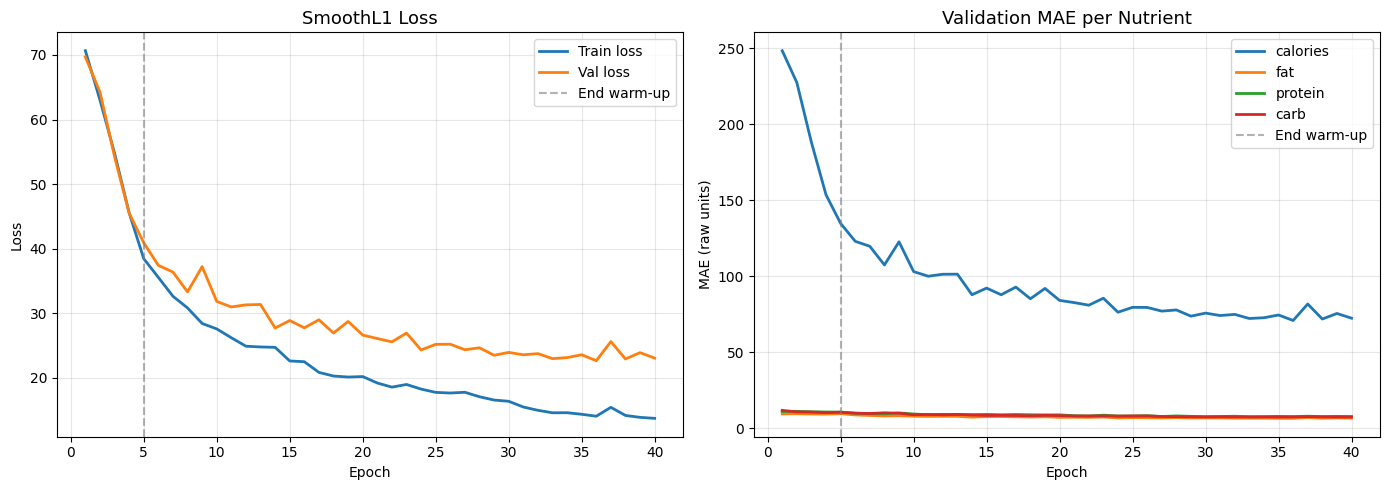

✓ Saved training_curves.png


In [10]:
# ── Training curves ───────────────────────────────────────────────────────────
epochs_ran = len(history['train_loss'])
ep_range   = range(1, epochs_ran + 1)
val_maes   = np.array(history['val_mae'])   # shape (epochs, NUM_TARGETS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(ep_range, history['train_loss'], label='Train loss', lw=2)
axes[0].plot(ep_range, history['val_loss'],   label='Val loss',   lw=2)
axes[0].axvline(WARMUP_EPOCHS, color='grey', linestyle='--', alpha=0.6, label='End warm-up')
axes[0].set_title('SmoothL1 Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE per target
for i, col in enumerate(TARGET_COLS):
    axes[1].plot(ep_range, val_maes[:, i], label=col, lw=2)
axes[1].axvline(WARMUP_EPOCHS, color='grey', linestyle='--', alpha=0.6, label='End warm-up')
axes[1].set_title('Validation MAE per Nutrient', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (raw units)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved training_curves.png')

In [11]:
# ── Load best checkpoint & evaluate on test set ───────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded checkpoint from epoch {ckpt["epoch"]}  (val_loss={ckpt["val_loss"]:.4f})')

test_loss, test_maes = evaluate(model, test_loader, criterion, device)

# Gather all predictions and targets for RMSE
model.eval()
all_preds   = []
all_targets = []
with torch.no_grad():
    for imgs, targets in test_loader:
        imgs    = imgs.to(device, non_blocking=True)
        preds   = model(imgs).cpu()
        all_preds.append(preds)
        all_targets.append(targets)

all_preds   = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

# ── Per-target metrics table ──────────────────────────────────────────────────
mae_per  = np.mean(np.abs(all_preds - all_targets), axis=0)
rmse_per = np.sqrt(np.mean((all_preds - all_targets) ** 2, axis=0))
mape_per = np.mean(np.abs((all_preds - all_targets) /
                           np.clip(np.abs(all_targets), 1e-6, None)), axis=0) * 100

print('\n' + '=' * 55)
print(f'TEST SET RESULTS   ({len(all_targets)} samples)')
print('=' * 55)
print(f'{"Target":<25} {"MAE":>8} {"RMSE":>8} {"MAPE%":>8}')
print('-' * 55)
for i, col in enumerate(TARGET_COLS):
    print(f'{col:<25} {mae_per[i]:>8.2f} {rmse_per[i]:>8.2f} {mape_per[i]:>8.1f}')
print('-' * 55)
print(f'{"Overall (mean)":<25} {mae_per.mean():>8.2f} {rmse_per.mean():>8.2f} {mape_per.mean():>8.1f}')
print('=' * 55)

Loaded checkpoint from epoch 36  (val_loss=22.6536)

TEST SET RESULTS   (326 samples)
Target                         MAE     RMSE    MAPE%
-------------------------------------------------------
calories                     65.25    93.53    101.5
fat                           5.40     8.13 5612064.5
protein                       6.91    10.61    151.6
carb                          6.99    10.31 3182399.5
-------------------------------------------------------
Overall (mean)               21.14    30.64 2198679.2


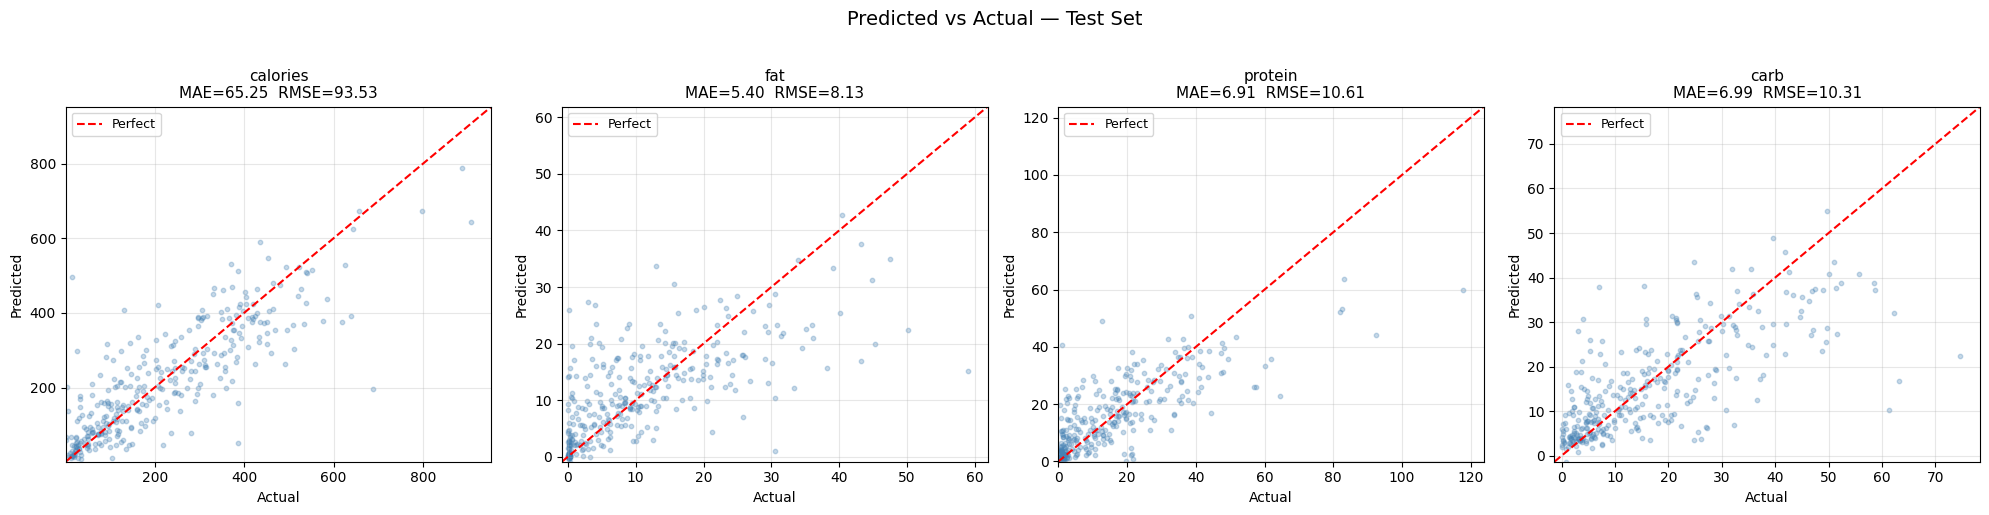

✓ Saved pred_vs_actual.png


In [12]:
# ── Predicted vs Actual scatter plots ────────────────────────────────────────
fig, axes = plt.subplots(1, NUM_TARGETS, figsize=(5 * NUM_TARGETS, 5))
if NUM_TARGETS == 1:
    axes = [axes]

for i, col in enumerate(TARGET_COLS):
    ax  = axes[i]
    y   = all_targets[:, i]
    yh  = all_preds[:, i]
    lim = (min(y.min(), yh.min()) * 0.95, max(y.max(), yh.max()) * 1.05)
    ax.scatter(y, yh, alpha=0.3, s=10, color='steelblue')
    ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect')
    ax.set_xlim(lim);  ax.set_ylim(lim)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{col}\nMAE={mae_per[i]:.2f}  RMSE={rmse_per[i]:.2f}', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Predicted vs Actual — Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved pred_vs_actual.png')

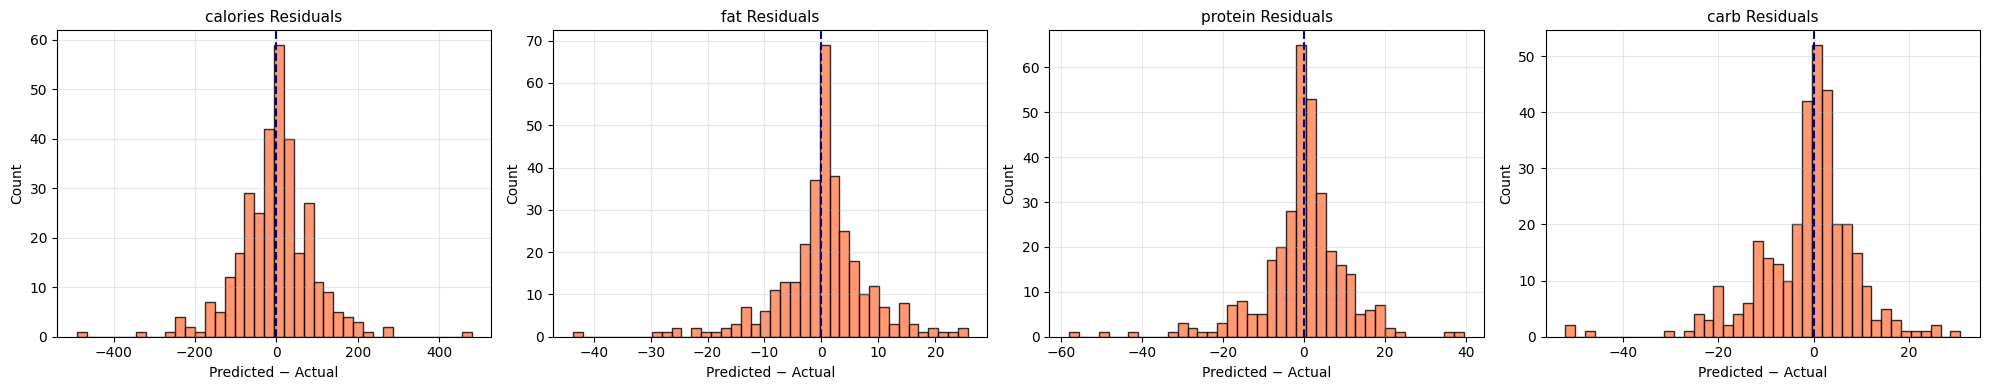

✓ Saved residuals.png


In [13]:
# ── Residual distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, NUM_TARGETS, figsize=(5 * NUM_TARGETS, 4))
if NUM_TARGETS == 1:
    axes = [axes]

for i, col in enumerate(TARGET_COLS):
    residuals = all_preds[:, i] - all_targets[:, i]
    axes[i].hist(residuals, bins=40, edgecolor='k', color='coral', alpha=0.8)
    axes[i].axvline(0, color='navy', lw=1.5, linestyle='--')
    axes[i].set_title(f'{col} Residuals', fontsize=11)
    axes[i].set_xlabel('Predicted − Actual')
    axes[i].set_ylabel('Count')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved residuals.png')

In [14]:
# ── Phase 3 Summary ───────────────────────────────────────────────────────────
print('=' * 60)
print('PHASE 3 SUMMARY')
print('=' * 60)
print(f'  Backbone        : {BACKBONE}')
print(f'  Total params    : {total:,}')
print(f'  Epochs trained  : {epochs_ran}  (of {NUM_EPOCHS} max)')
print(f'  Best val loss   : {best_val_loss:.4f}')
print(f'  Test loss       : {test_loss:.4f}')
print(f'  Targets         : {TARGET_COLS}')
print()
print(f'  Per-target Test MAE:')
for i, col in enumerate(TARGET_COLS):
    print(f'    {col:<25} MAE={mae_per[i]:.2f}  RMSE={rmse_per[i]:.2f}  MAPE={mape_per[i]:.1f}%')
print()
print(f'  Checkpoint saved: {CKPT_PATH}')
print('=' * 60)
print('✓ Phase 3 complete — ready for Phase 4: Improvements / Report')

PHASE 3 SUMMARY
  Backbone        : resnet50
  Total params    : 24,560,196
  Epochs trained  : 40  (of 40 max)
  Best val loss   : 22.6536
  Test loss       : 20.6669
  Targets         : ['calories', 'fat', 'protein', 'carb']

  Per-target Test MAE:
    calories                  MAE=65.25  RMSE=93.53  MAPE=101.5%
    fat                       MAE=5.40  RMSE=8.13  MAPE=5612064.5%
    protein                   MAE=6.91  RMSE=10.61  MAPE=151.6%
    carb                      MAE=6.99  RMSE=10.31  MAPE=3182399.5%

  Checkpoint saved: best_model.pt
✓ Phase 3 complete — ready for Phase 4: Improvements / Report
